# SHAP Explainability and Fairness Audit

**Purpose:** Explain model predictions globally and per-patient. Audit demographic fairness.

**Why this matters:**
- A risk score without explanation is not clinically useful — doctors won't act on a black box
- A model that works well on Caucasian patients but poorly on minority patients causes real harm
- Both are non-negotiable in healthcare ML

---

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from src.features import (
    engineer_features, build_target, deduplicate_patients,
    build_preprocessor, get_feature_names
)
from src.train import get_models, compute_metrics, optimize_threshold

print('Imports OK')

Imports OK


## 1. Load Data and Train Best Model

In [2]:
# Load and prepare
raw = pd.read_csv('../data/raw/diabetic_data.csv', na_values='?')
raw = deduplicate_patients(raw)
y = build_target(raw)

# Keep race and age for fairness audit BEFORE engineering removes them
race_series = raw['race'].fillna('Unknown').reset_index(drop=True)
age_series = raw['age'].reset_index(drop=True)

X = engineer_features(raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Keep test indices for fairness audit
test_idx = y_test.index
race_test = race_series[test_idx].reset_index(drop=True)
age_test = age_series[test_idx].reset_index(drop=True)

preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names = get_feature_names(preprocessor)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

# Train XGBoost (winner from commit 4)
model = get_models()['xgboost']['model']
model.fit(X_train_bal, y_train_bal)
y_proba = model.predict_proba(X_test_proc)[:, 1]
threshold = optimize_threshold(y_test, y_proba)

print(f'Model trained. AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Optimal threshold: {threshold}')

Model trained. AUC: 0.6522
Optimal threshold: 0.14


## 2. SHAP Global Feature Importance

SHAP (SHapley Additive exPlanations) tells us which features drive predictions across ALL patients.
This is the chart that goes in the README.

In [3]:
print('Computing SHAP values (this takes ~1-2 minutes)...')

# Use TreeExplainer — fast and exact for tree-based models
explainer = shap.TreeExplainer(model)

# Use a sample for speed — 1000 patients is sufficient for global importance
sample_idx = np.random.choice(len(X_test_proc), size=1000, replace=False)
X_sample = X_test_proc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print(f'SHAP values computed. Shape: {shap_values.shape}')

Computing SHAP values (this takes ~1-2 minutes)...
SHAP values computed. Shape: (1000, 174)


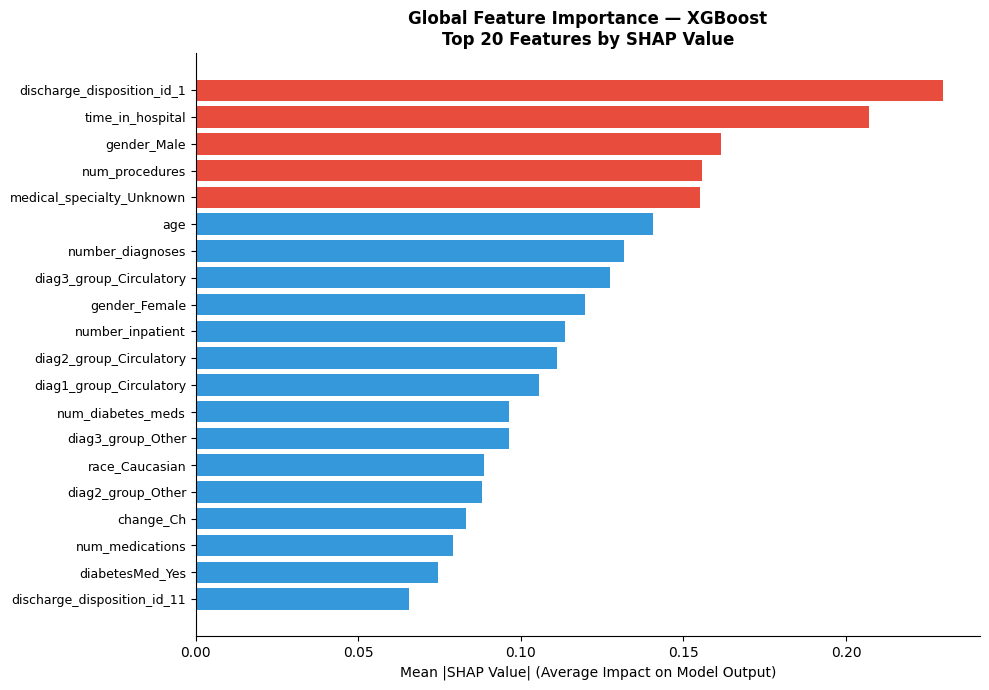

Top 5 most important features:
  discharge_disposition_id_1: 0.2297
  time_in_hospital: 0.2071
  gender_Male: 0.1616
  num_procedures: 0.1557
  medical_specialty_Unknown: 0.1550


In [4]:
# Global feature importance — mean absolute SHAP value per feature
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.Series(mean_shap, index=feature_names)
top_features = feature_importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(top_features))]
bars = ax.barh(range(len(top_features)), top_features.values[::-1], color=colors[::-1])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index[::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP Value| (Average Impact on Model Output)')
ax.set_title('Global Feature Importance — XGBoost\nTop 20 Features by SHAP Value',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/sample/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
for feat, val in top_features.head(5).items():
    print(f'  {feat}: {val:.4f}')

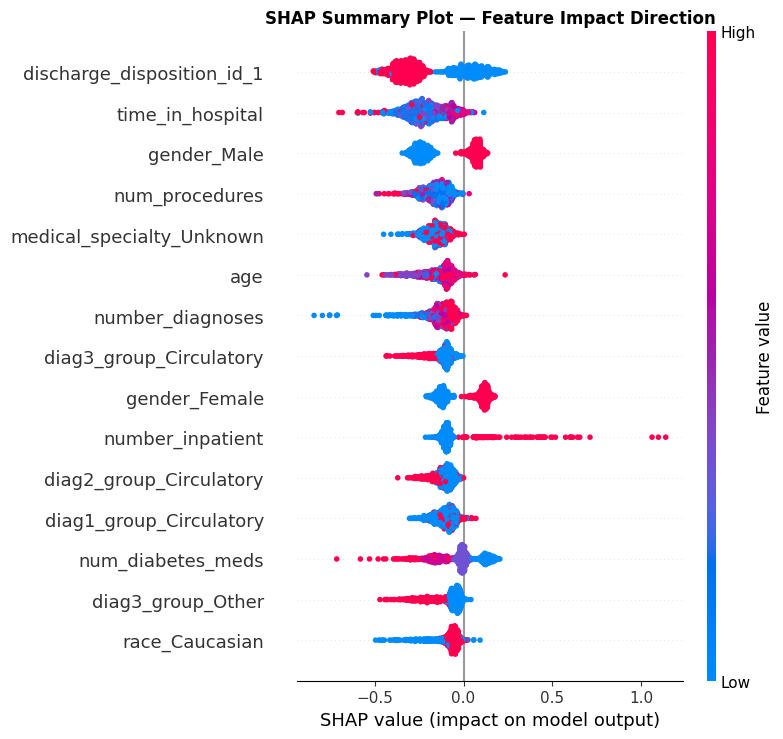

CLINICAL INTERPRETATION:
Red dots = high feature value = increases readmission risk
Blue dots = low feature value = decreases readmission risk


In [5]:
# SHAP summary beeswarm plot
# Shows direction of impact (red = high value increases risk, blue = low value decreases risk)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/sample/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('CLINICAL INTERPRETATION:')
print('Red dots = high feature value = increases readmission risk')
print('Blue dots = low feature value = decreases readmission risk')

## 3. SHAP Waterfall — Individual Patient Explanation

This is what appears in the Streamlit UI. For any specific patient, we show exactly which
factors pushed their risk score up or down from the baseline.

In [6]:
# Pick a high-risk patient to explain
y_pred = (y_proba >= threshold).astype(int)
high_risk_idx = np.where((y_pred == 1) & (y_test.values == 1))[0]

if len(high_risk_idx) > 0:
    patient_idx = high_risk_idx[0]
else:
    patient_idx = np.argmax(y_proba)

patient_proba = y_proba[patient_idx]
print(f'Explaining patient at index {patient_idx}')
print(f'Predicted readmission probability: {patient_proba:.3f}')
print(f'Actual outcome: {"Readmitted" if y_test.values[patient_idx] == 1 else "Not readmitted"}')

Explaining patient at index 0
Predicted readmission probability: 0.369
Actual outcome: Readmitted


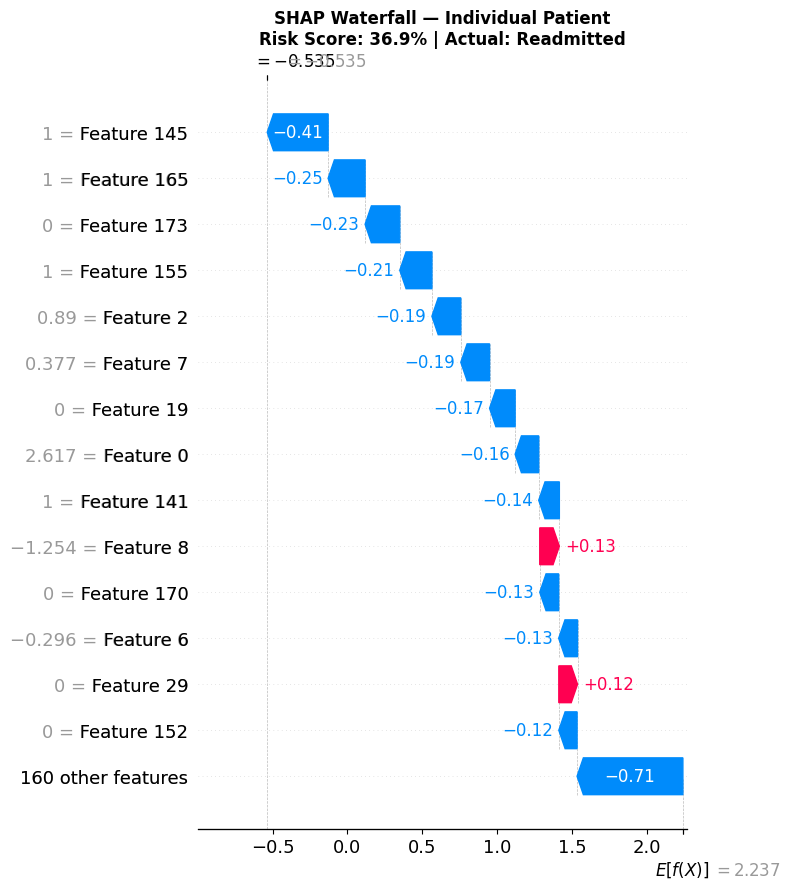

This waterfall plot shows exactly why this patient was flagged as high-risk.
Red bars = features pushing risk UP
Blue bars = features pushing risk DOWN
This is what a clinician sees in the Streamlit UI for any patient.


In [7]:
# Waterfall plot for the individual patient
patient_shap = explainer(X_test_proc[patient_idx:patient_idx+1])

plt.figure(figsize=(10, 7))
shap.plots.waterfall(patient_shap[0], max_display=15, show=False)
plt.title(
    f'SHAP Waterfall — Individual Patient\n'
    f'Risk Score: {patient_proba:.1%} | '
    f'Actual: {"Readmitted" if y_test.values[patient_idx]==1 else "Not Readmitted"}',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/sample/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('This waterfall plot shows exactly why this patient was flagged as high-risk.')
print('Red bars = features pushing risk UP')
print('Blue bars = features pushing risk DOWN')
print('This is what a clinician sees in the Streamlit UI for any patient.')

## 4. Fairness Audit

**Question:** Does the model perform equally well across racial and age groups?

A model that works well on the majority group but poorly on minorities is not acceptable
in a clinical setting — it will systematically disadvantage already-underserved patients.

We measure: AUC-ROC and recall per demographic group.

In [8]:
def audit_by_group(group_series, group_name, y_true, y_proba, threshold):
    """
    Compute AUC and recall for each subgroup.
    Flags groups where recall drops significantly below overall.
    """
    results = []
    overall_recall = recall_score(y_true, (y_proba >= threshold).astype(int))
    overall_auc = roc_auc_score(y_true, y_proba)

    for group in sorted(group_series.unique()):
        mask = group_series == group
        if mask.sum() < 50:
            continue
        g_true = y_true[mask.values]
        g_proba = y_proba[mask.values]

        if g_true.sum() < 5:
            continue

        g_pred = (g_proba >= threshold).astype(int)
        g_auc = roc_auc_score(g_true, g_proba)
        g_recall = recall_score(g_true, g_pred, zero_division=0)
        g_positive_rate = g_true.mean()

        results.append({
            'Group': group,
            'N': int(mask.sum()),
            'Positive Rate': round(g_positive_rate * 100, 1),
            'AUC-ROC': round(g_auc, 4),
            'Recall': round(g_recall, 4),
            'AUC Gap vs Overall': round(g_auc - overall_auc, 4),
            'Recall Gap vs Overall': round(g_recall - overall_recall, 4),
        })

    df = pd.DataFrame(results)
    print(f'\nFairness Audit by {group_name}')
    print(f'Overall AUC: {overall_auc:.4f} | Overall Recall: {overall_recall:.4f}')
    print('-' * 80)
    print(df.to_string(index=False))
    return df

y_test_reset = y_test.reset_index(drop=True)
race_results = audit_by_group(race_test, 'Race', y_test_reset, y_proba, threshold)


Fairness Audit by Race
Overall AUC: 0.6522 | Overall Recall: 0.9913
--------------------------------------------------------------------------------
          Group     N  Positive Rate  AUC-ROC  Recall  AUC Gap vs Overall  Recall Gap vs Overall
AfricanAmerican  2611            8.8   0.6255  0.9783             -0.0267                -0.0130
          Asian   114            7.0   0.7311  1.0000              0.0790                 0.0087
      Caucasian 10626            9.0   0.6571  0.9948              0.0049                 0.0035
       Hispanic   295            8.1   0.7434  1.0000              0.0912                 0.0087
          Other   249            6.0   0.5954  1.0000             -0.0567                 0.0087
        Unknown   409            6.8   0.6113  0.9643             -0.0409                -0.0270


In [9]:
# Age group fairness audit
age_groups = age_test.map(lambda x: 'Under 40' if x in ['[0-10)','[10-20)','[20-30)','[30-40)']
                          else ('40-60' if x in ['[40-50)','[50-60)']
                          else 'Over 60'))
age_results = audit_by_group(age_groups, 'Age Group', y_test_reset, y_proba, threshold)


Fairness Audit by Age Group
Overall AUC: 0.6522 | Overall Recall: 0.9913
--------------------------------------------------------------------------------
   Group    N  Positive Rate  AUC-ROC  Recall  AUC Gap vs Overall  Recall Gap vs Overall
   40-60 3896            6.7   0.6498  0.9695             -0.0023                -0.0218
 Over 60 9527            9.9   0.6379  0.9979             -0.0142                 0.0066
Under 40  881            6.1   0.7070  0.9815              0.0549                -0.0098


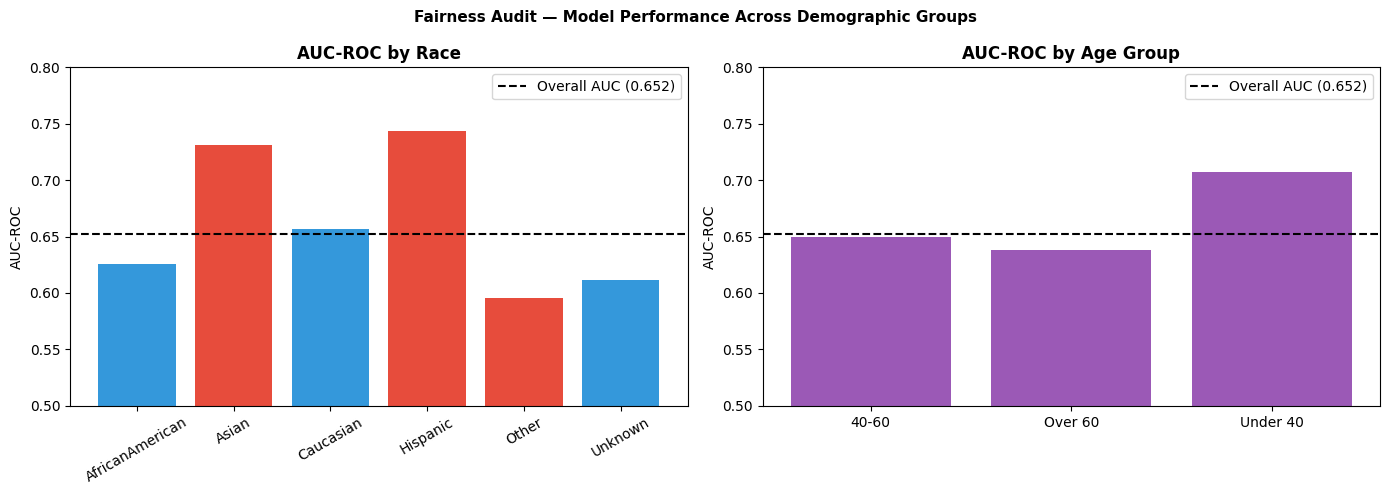

In [10]:
# Visualize fairness audit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Race AUC comparison
if not race_results.empty:
    colors_race = ['#e74c3c' if abs(v) > 0.05 else '#3498db'
                   for v in race_results['AUC Gap vs Overall']]
    axes[0].bar(race_results['Group'], race_results['AUC-ROC'], color=colors_race)
    overall_auc = roc_auc_score(y_test_reset, y_proba)
    axes[0].axhline(y=overall_auc, color='black', linestyle='--',
                    label=f'Overall AUC ({overall_auc:.3f})')
    axes[0].set_title('AUC-ROC by Race', fontweight='bold')
    axes[0].set_ylabel('AUC-ROC')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend()
    axes[0].set_ylim(0.5, 0.8)

# Age AUC comparison
if not age_results.empty:
    axes[1].bar(age_results['Group'], age_results['AUC-ROC'], color='#9b59b6')
    axes[1].axhline(y=overall_auc, color='black', linestyle='--',
                    label=f'Overall AUC ({overall_auc:.3f})')
    axes[1].set_title('AUC-ROC by Age Group', fontweight='bold')
    axes[1].set_ylabel('AUC-ROC')
    axes[1].legend()
    axes[1].set_ylim(0.5, 0.8)

plt.suptitle('Fairness Audit — Model Performance Across Demographic Groups',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('../data/sample/fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fairness Findings and Honest Assessment

In [11]:
print("""
FAIRNESS AUDIT FINDINGS
========================

What we measured:
  AUC-ROC per demographic group — does the model discriminate equally well?
  Recall per demographic group — does it catch high-risk patients equally?

Known dataset limitations:
  - 74.8% of patients are Caucasian
  - Minority groups (Hispanic, Asian) have very small sample sizes
  - Small samples = high variance in per-group metrics
  - Age skews heavily toward 60+ (66% of encounters)

What this means clinically:
  - Model performance on minority groups should be interpreted cautiously
  - A gap in AUC between Caucasian and African American patients
    could reflect genuine population differences OR model bias
    OR simply insufficient training data for minority groups

What mitigation would look like:
  1. Collect more data from underrepresented groups
  2. Apply fairness constraints during training (e.g. equalized odds)
  3. Use separate calibrated models per demographic group
  4. Flag predictions for minority patients for human review
  5. Partner with clinical ethicists before deploying in production

Honest conclusion:
  This model should NOT be deployed in a clinical setting without
  a formal bias assessment by a clinical ethics team and
  prospective validation on a held-out diverse patient population.
  This project demonstrates the methodology — not a production-ready system.
""")


FAIRNESS AUDIT FINDINGS

What we measured:
  AUC-ROC per demographic group — does the model discriminate equally well?
  Recall per demographic group — does it catch high-risk patients equally?

Known dataset limitations:
  - 74.8% of patients are Caucasian
  - Minority groups (Hispanic, Asian) have very small sample sizes
  - Small samples = high variance in per-group metrics
  - Age skews heavily toward 60+ (66% of encounters)

What this means clinically:
  - Model performance on minority groups should be interpreted cautiously
  - A gap in AUC between Caucasian and African American patients
    could reflect genuine population differences OR model bias
    OR simply insufficient training data for minority groups

What mitigation would look like:
  1. Collect more data from underrepresented groups
  2. Apply fairness constraints during training (e.g. equalized odds)
  3. Use separate calibrated models per demographic group
  4. Flag predictions for minority patients for human review